In [70]:
# Importer NumPy pour les calculs numériques
import numpy as np
# Importer Matplotlib pour créer des graphiques
import matplotlib.pyplot as plt
# Importer Pandas pour manipuler les données
import pandas as pd


# Lire le fichier CSV contenant les données du Bitcoin
bitcoin = pd.read_csv('BTC-EUR.csv',index_col='Date',parse_dates=True)


# Afficher les 5 premières lignes du DataFrame
bitcoin.head()

,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2011-10-04,3.700,3.821,3.746,3.750,3.750,1357
2011-10-05,3.750,3.820,3.650,3.676,3.676,3349
2011-10-06,3.676,3.743,3.450,3.550,3.550,6642
2011-10-07,3.550,3.590,2.900,3.293,3.293,7135
2011-10-08,3.293,3.283,2.872,2.890,2.890,2007


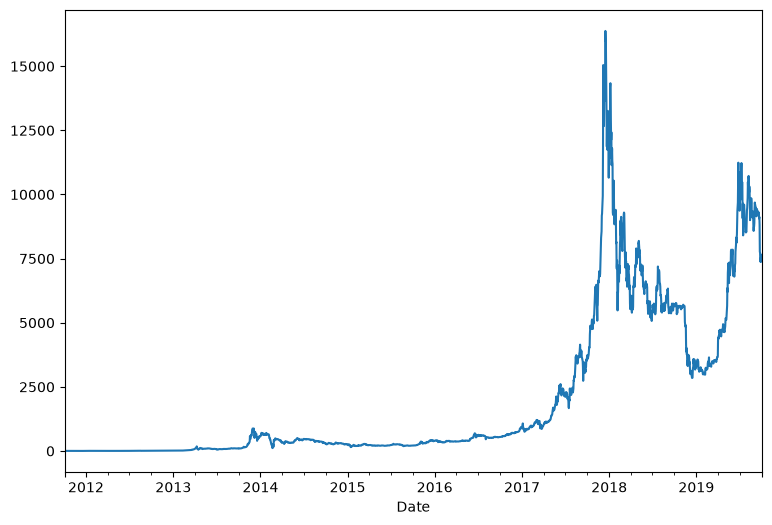

DatetimeIndex(['2011-10-04', '2011-10-05', '2011-10-06', '2011-10-07',
               '2011-10-08', '2011-10-09', '2011-10-10', '2011-10-11',
               '2011-10-12', '2011-10-13',
               ...
               '2019-09-25', '2019-09-26', '2019-09-27', '2019-09-28',
               '2019-09-29', '2019-09-30', '2019-10-01', '2019-10-02',
               '2019-10-03', '2019-10-04'],
              dtype='datetime64[us]', name='Date', length=2923, freq=None)

In [65]:
bitcoin['Close'].plot(figsize=(9, 6))
plt.show()
bitcoin.index

                   Open         High          Low        Close    Adj Close  \
Date                                                                          
2019-01-01  3247.790039  3380.320068  3214.340088  3372.090088  3372.090088   
2019-01-02  3372.090088  3482.489990  3328.800049  3468.399902  3468.399902   
2019-01-03  3468.399902  3472.800049  3319.760010  3345.330078  3345.330078   
2019-01-04  3345.330078  3400.840088  3316.639893  3370.939941  3370.939941   
2019-01-05  3370.939941  3423.320068  3352.530029  3359.159912  3359.159912   

              Volume  
Date                  
2019-01-01  28207690  
2019-01-02  39302386  
2019-01-03  38242406  
2019-01-04  33665676  
2019-01-05  21586634  


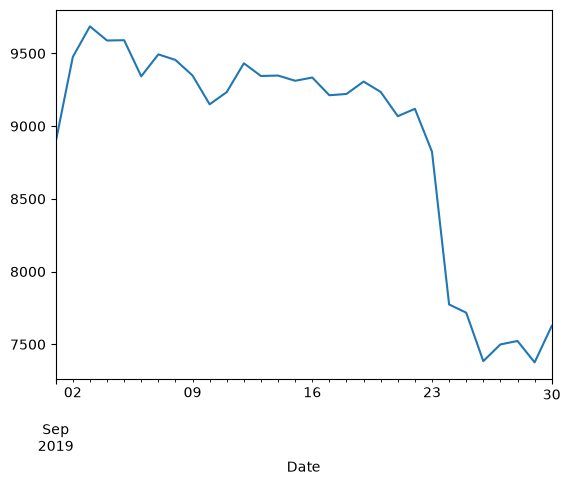

In [84]:
##################################################
# Time series
##################################################


# Sélectionner uniquement l'année 2019
bitcoin_2019 = bitcoin.loc['2019']
bitcoin_2019_09 = bitcoin.loc['2019-09']
print(bitcoin_2019.head())
#bitcoin_2019['Close'].plot()
bitcoin_2019_09['Close'].plot()
plt.show()



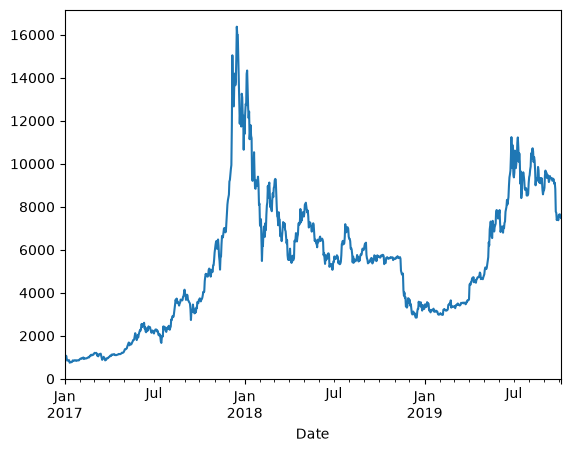

In [87]:
bitcoin_2017_2019 = bitcoin.loc['2017':'2019']['Close'].plot()
plt.show()

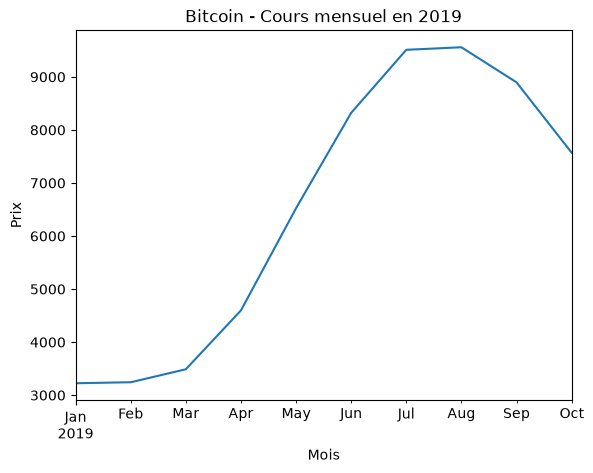

In [104]:
# Calculer l'evolution' du bitcoin par mois 
#bitcoin_Months_2019 = bitcoin.loc['2019','Close'].resample('ME').plot()
bitcoin_Months_2019 = bitcoin.loc['2019', 'Close'].resample('ME').mean().plot()
plt.title('Bitcoin - Cours mensuel en 2019')
plt.xlabel('Mois')
plt.ylabel('Prix')
plt.show()



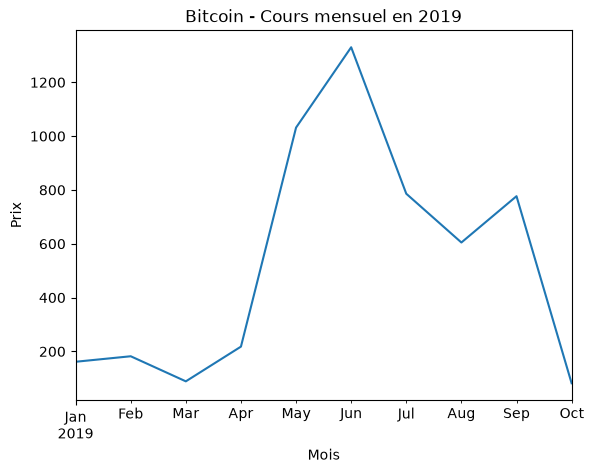

In [ ]:
# Calculer l'evolution' du bitcoin par mois 

bitcoin_Months_2019 = bitcoin.loc['2019', 'Close'].resample('ME').std().plot()
plt.title('Bitcoin - Cours  en 2019')
plt.xlabel('Mois')
plt.ylabel('Prix')
plt.show()



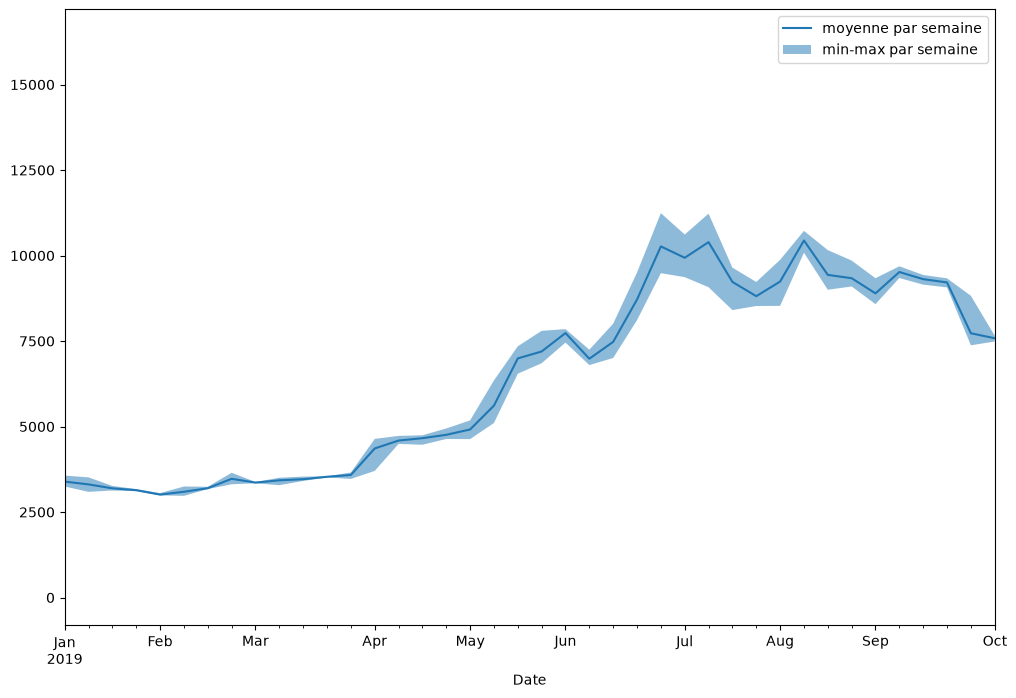

In [116]:
# Regrouper les cours de clôture par semaine
# et calculer la moyenne, l'écart-type, le minimum et le maximum
m = bitcoin['Close'].resample('W').agg(['mean', 'std', 'min', 'max'])

# Créer la figure
plt.figure(figsize=(12, 8))

# Tracer la moyenne hebdomadaire pour l'année 2019
m['mean']['2019'].plot(label='moyenne par semaine')

# Ajouter la zone entre le minimum et le maximum
plt.fill_between(
    m.index,
    m['max'],
    m['min'],
    alpha=0.5,
    label='min-max par semaine'
)

# Afficher la légende
plt.legend()

# Afficher le graphique
plt.show()

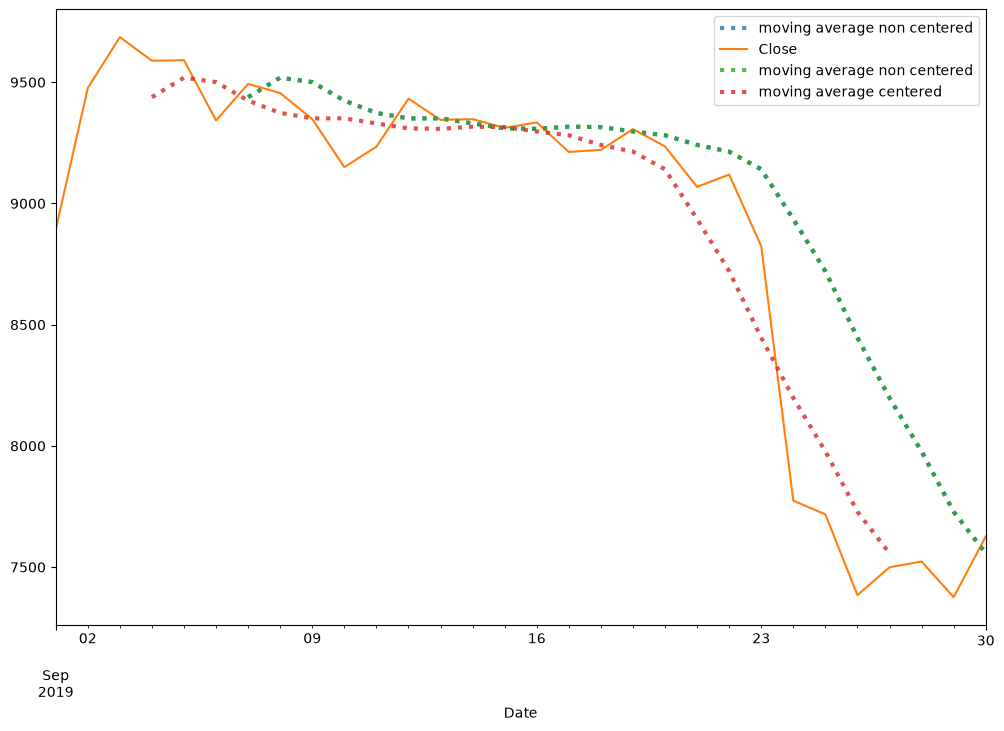

In [ ]:
#######################################
# Mooving average ->  Rolling windows
#######################################

# Créer une figure de taille 12 × 8
plt.figure(figsize=(12, 8))

bitcoin.loc['2019-09','Close'].rolling(window=7).mean().plot(
    label='moving average non centered',
    lw=3,
    ls=':',
    alpha=0.8
)

# Tracer le cours de clôture du Bitcoin en 2019
bitcoin.loc['2019-09', 'Close'].plot()

# Calculer et tracer la moyenne mobile sur 7 jours
bitcoin.loc['2019-09', 'Close'].rolling(window=7).mean().plot(
    label='moving average non centered',
    lw=3,
    ls=':',
    alpha=0.8
)
bitcoin.loc['2019-09', 'Close'].rolling(window=7,center=True).mean().plot(
    label='moving average centered',
    lw=3,
    ls=':',
    alpha=0.8
)


# Afficher la légende
plt.legend()

# Afficher le graphique
plt.show()

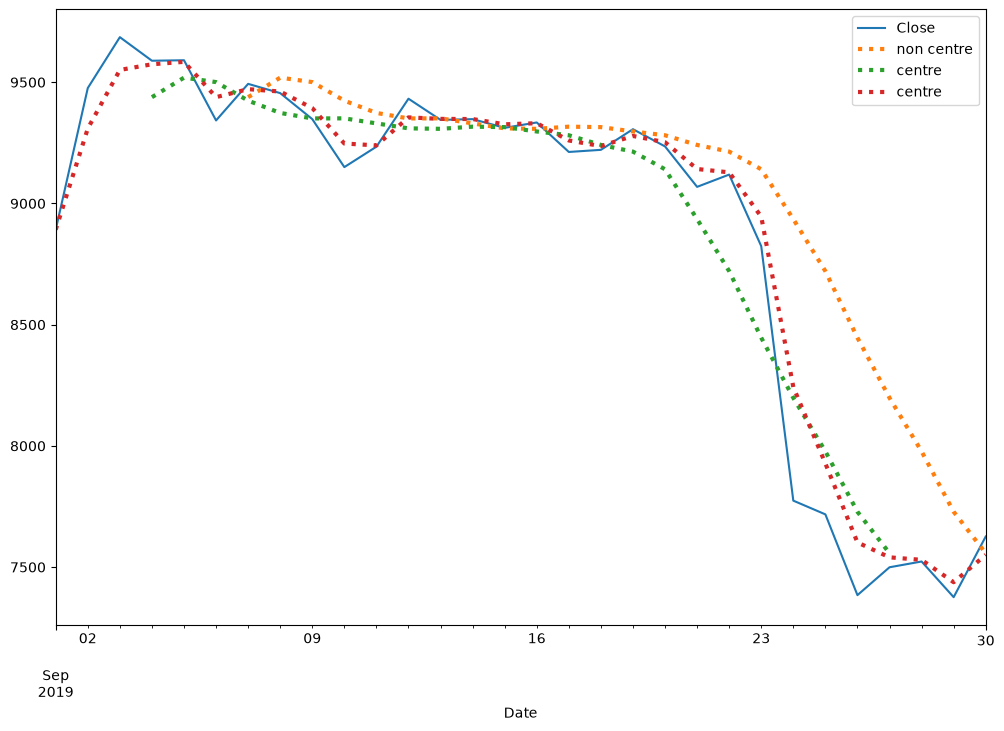

In [121]:
#######################################
# Exponantial weighteding->  Rolling windows
#######################################
# Créer une figure de taille 12 × 8
plt.figure(figsize=(12, 8))

# Afficher le cours de clôture du Bitcoin en septembre 2019
bitcoin.loc['2019-09', 'Close'].plot()

# Calculer la moyenne mobile sur 7 jours, sans centrage
bitcoin.loc['2019-09', 'Close'].rolling(window=7).mean().plot(
    label='non centre',
    lw=3,
    ls=':'
)

# Calculer la moyenne mobile sur 7 jours, centrée
bitcoin.loc['2019-09', 'Close'].rolling(
    window=7,
    center=True
).mean().plot(
    label='centre',
    lw=3,
    ls=':'
)

# Calculer une moyenne exponentielle avec alpha = 0.6
bitcoin.loc['2019-09', 'Close'].ewm(
    alpha=0.6
).mean().plot(
    label='centre',
    lw=3,
    ls=':'
)

# Afficher la légende
plt.legend()

# Afficher le graphique
plt.show()

array([<Axes: xlabel='Date'>, <Axes: xlabel='Date'>], dtype=object)

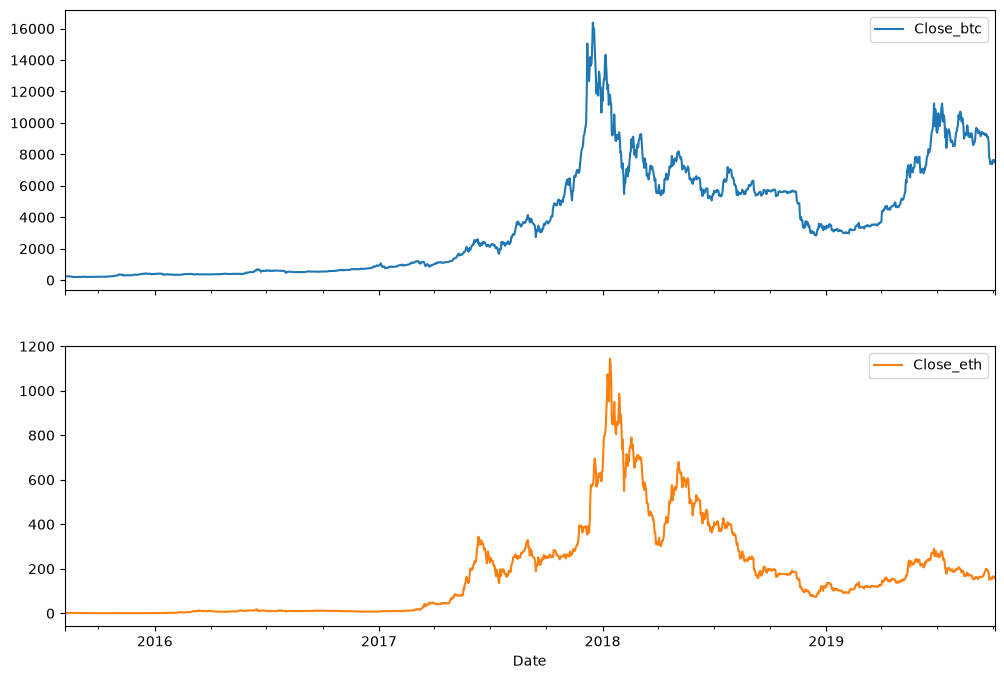

In [129]:
#######################################
# Assembler datasets
#######################################

# Charger les données Ethereum depuis le fichier CSV
# 'Date' devient l'index et est convertie automatiquement en date
ethereum = pd.read_csv(
    'ETH-EUR.csv',
    index_col='Date',
    parse_dates=True
)

# Fusionner les données Bitcoin et Ethereum
# 'outer' conserve toutes les dates présentes dans l'un ou l'autre fichier
# Les suffixes permettent de différencier les colonnes communes
btc_eth = pd.merge(
    bitcoin,
    ethereum,
    on='Date',
    how='inner',
    suffixes=('_btc', '_eth')
)
btc_eth [['Close_btc', 'Close_eth']]. plot(subplots = True, figsize=(12,8))


In [130]:
btc_eth[['Close_btc', 'Close_eth']].corr()

,Close_btc,Close_eth
Close_btc,1.000000,0.791416
Close_eth,0.791416,1.000000
